<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/reservoir/ensamble_based_modelling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import importlib.util
import subprocess
import sys

if importlib.util.find_spec("neqsim") is None:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "neqsim",
        ]
    )

print("NeqSim is available. ERT remains an optional orchestration layer.")

NeqSim is available. ERT remains an optional orchestration layer.


# Ensemble-based integrated reservoir and process modelling

**Intended audience.** Reservoir, production, and process engineers who know basic
material balance and Python and want to propagate subsurface uncertainty into a
surface-facility decision.

**Prerequisites.** Familiarity with pressure, production rate, thermodynamic phase
equilibrium, and simple probability summaries. No local model files or proprietary data
are required.

Integrated modelling connects a reservoir forecast to a surface-process calculation.
The reservoir side predicts uncertain wellstream rates and pressure. NeqSim represents
the fluid, flashes the phases, connects streams and unit operations, and calculates
separator products and compression power. The ensemble view shows not only a single
forecast but also the probability of exceeding a facility limit.

The original notebook introduced ERT and NeqSim but called APIs that do not exist. This
repaired version preserves that teaching objective with a reproducible synthetic
reservoir ensemble and real released NeqSim process objects.

**Learning objectives**

1. Explain the boundary between an ensemble orchestrator and a process simulator.
2. Generate prior reservoir realizations and compare them with synthetic observations.
3. Apply a transparent ensemble-smoother update and inspect uncertainty reduction.
4. Build and run a three-phase separation and gas-compression model in NeqSim.
5. Transfer ensemble rates into the facility model through a documented table contract.
6. Quantify bottleneck probabilities and constrained production.
7. Export parameter and response tables that can be adapted to an ERT workflow.

## The ERT framework and the modelling boundary

[ERT](https://github.com/equinor/ert) means *Ensemble based Reservoir Tool*. It is an
open-source workflow and data-assimilation framework for ensembles of dynamical models.
It is **not itself a reservoir simulator**. In a production project, ERT launches an
external simulator or forward model for every realization, collects responses, and can
update uncertain parameters with ensemble-smoother methods such as ES or ES-MDA.

NeqSim is the process and thermodynamics engine in this example. A robust coupling does
not exchange hidden Python objects. It exchanges explicit, unit-labelled files or tables:
uncertain parameters go into the forward model, and predicted reservoir and facility
responses come back.

ERT is optional here because a full ERT installation and a site-specific reservoir
simulator are not needed to learn the coupling. The notebook creates compatible parameter
and response tables and implements one transparent ensemble-smoother update in NumPy.
See the [ERT configuration guide](https://ert.readthedocs.io/en/latest/getting_started/configuration/poly_new/guide.html)
when adapting the example to a managed ensemble workflow.

In [2]:
import importlib.metadata
import importlib.util
import platform
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import neqsim
import numpy as np
import pandas as pd

ert_available = importlib.util.find_spec("ert") is not None
ert_version = (
    importlib.metadata.version("ert")
    if ert_available
    else "not installed (optional)"
)

neqsim_version = importlib.metadata.version("neqsim")

print(f"NeqSim version: {neqsim_version}")
print(f"Python version: {platform.python_version()}")
print(f"ERT status: {ert_version}")

NeqSim version: 3.16.0
Python version: 3.12.13
ERT status: not installed (optional)


## A reproducible integration contract

The coupling uses four explicit fields: realization identifier, time, reservoir pressure,
and raw wellstream mass rate. Units are part of the column names. This makes the interface
inspectable, testable, and suitable for CSV exchange with ERT or another orchestrator.

The process model receives a raw wellstream rate in $\mathrm{kg/s}$ and returns separated
gas, hydrocarbon liquid, produced water, compressor power, and outlet temperature. The
reservoir model never reaches inside a NeqSim object, and NeqSim never assumes how the
reservoir ensemble was generated.

In [3]:
@dataclass(frozen=True)
class ReservoirProcessExchange:
    realization_id: int
    time_year: float
    reservoir_pressure_bara: float
    wellstream_rate_kg_s: float


exchange_schema = {
    "realization_id": "dimensionless integer",
    "time_year": "year",
    "reservoir_pressure_bara": "bar absolute",
    "wellstream_rate_kg_s": "kg/s",
}

print("Operational exchange schema:")
for field_name, unit in exchange_schema.items():
    print(f"  {field_name}: {unit}")

Operational exchange schema:
  realization_id: dimensionless integer
  time_year: year
  reservoir_pressure_bara: bar absolute
  wellstream_rate_kg_s: kg/s


## 1. Engineering model, assumptions, and limits

The reservoir side is a compact decline-and-pressure model used to demonstrate uncertainty
propagation. For realization $i$, the raw wellstream rate is

$$
q_i(t) = q_{0,i}\exp[-d_i(1-0.45a_i)t]
$$

where $q_i$ is in $\mathrm{kg/s}$, $q_{0,i}$ is the initial rate, $d_i$ is an annual
decline constant, $a_i$ is a dimensionless aquifer-support factor, and $t$ is time in
years. Reservoir pressure follows

$$
p_i(t) = p_{\min} + (p_{0,i}-p_{\min})\exp[-0.075(1+0.8d_i)t]
$$

Pressure $p_i$ and the abandonment limit $p_{\min}$ are in bar absolute.

These equations are synthetic and are not a substitute for a calibrated reservoir
simulator. Their purpose is to expose the integration pattern. The NeqSim facility model,
however, uses real thermodynamic flashes and process equipment. It assumes steady state,
one fixed wellstream composition, equilibrium separation, no pressure loss outside the
specified choke, and constant compressor efficiency.

In [4]:
SEED = 20260729
ENSEMBLE_SIZE = 80
FORECAST_YEARS = np.arange(0.0, 16.0, 1.0)
HISTORY_YEARS = np.arange(1.0, 6.0, 1.0)
ABANDONMENT_PRESSURE_BARA = 85.0

rng = np.random.default_rng(SEED)

plt.style.use("seaborn-v0_8-whitegrid")
COLORS = {
    "blue": "#0072B2",
    "orange": "#E69F00",
    "green": "#009E73",
    "red": "#D55E00",
    "purple": "#CC79A7",
    "gray": "#6B7280",
}

print(f"Deterministic ensemble seed: {SEED}")
print(f"Number of realizations: {ENSEMBLE_SIZE}")

Deterministic ensemble seed: 20260729
Number of realizations: 80


## 2. Workflow overview

The overview below is a model/process/workflow visual. Blue boxes are uncertain reservoir
work, orange is the explicit data boundary, and green boxes are real NeqSim calculations.
The final decision is based on an ensemble of facility outcomes rather than a single
deterministic rate.

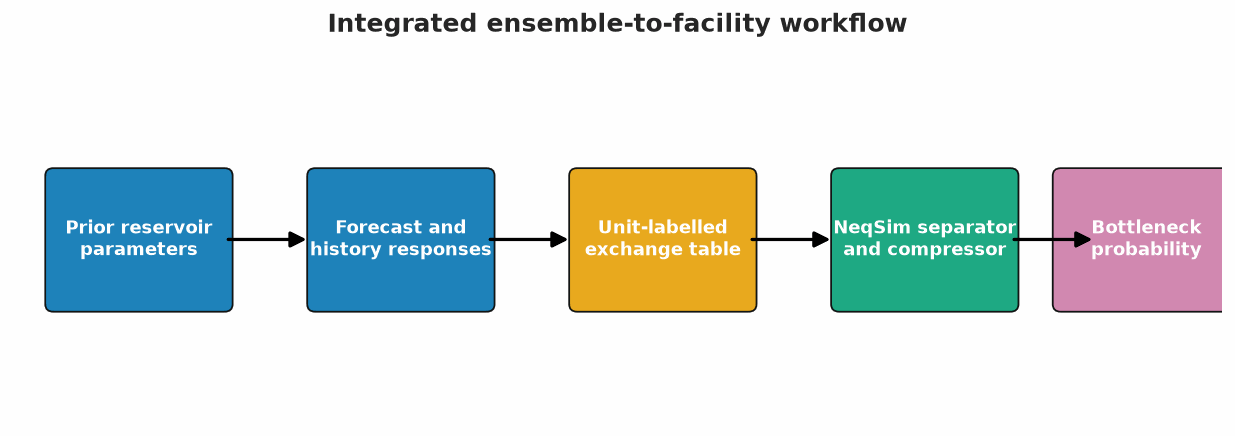

In [5]:
from matplotlib.patches import FancyArrowPatch, FancyBboxPatch

figure, axis = plt.subplots(figsize=(12, 3.8))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 4.0)
axis.axis("off")

workflow_nodes = [
    (0.4, "Prior reservoir\nparameters", COLORS["blue"]),
    (3.0, "Forecast and\nhistory responses", COLORS["blue"]),
    (5.6, "Unit-labelled\nexchange table", COLORS["orange"]),
    (8.2, "NeqSim separator\nand compressor", COLORS["green"]),
    (10.4, "Bottleneck\nprobability", COLORS["purple"]),
]

for x_position, label, color in workflow_nodes:
    box = FancyBboxPatch(
        (x_position, 1.25),
        1.7,
        1.35,
        boxstyle="round,pad=0.08",
        facecolor=color,
        edgecolor="black",
        alpha=0.88,
    )
    axis.add_patch(box)
    axis.text(
        x_position + 0.85,
        1.93,
        label,
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        weight="bold",
    )

for start_x in [2.1, 4.7, 7.3, 9.9]:
    arrow = FancyArrowPatch(
        (start_x, 1.93),
        (start_x + 0.85, 1.93),
        arrowstyle="-|>",
        mutation_scale=18,
        linewidth=1.8,
        color="black",
    )
    axis.add_patch(arrow)

axis.set_title(
    "Integrated ensemble-to-facility workflow",
    fontsize=14,
    weight="bold",
)
plt.show()

**Interpretation.** The orange exchange table is a deliberate architecture choice. It
supports testing, provenance, unit checking, and replacement of the synthetic model by a
reservoir simulator without changing the NeqSim process workflow.

## 3. Generate the prior reservoir ensemble

The uncertain parameters are initial wellstream rate $q_0$, annual decline $d$, aquifer
support $a$, and initial reservoir pressure $p_0$. Bounds represent an illustrative
screening range, not a field benchmark. Every realization is independent and reproducible.

In [6]:
prior_parameters = pd.DataFrame(
    {
        "realization_id": np.arange(ENSEMBLE_SIZE),
        "initial_rate_kg_s": rng.uniform(58.0, 102.0, ENSEMBLE_SIZE),
        "decline_per_year": rng.uniform(0.075, 0.185, ENSEMBLE_SIZE),
        "aquifer_support": rng.uniform(0.0, 0.65, ENSEMBLE_SIZE),
        "initial_pressure_bara": rng.uniform(245.0, 285.0, ENSEMBLE_SIZE),
    }
)

parameter_bounds = {
    "initial_rate_kg_s": (45.0, 115.0),
    "decline_per_year": (0.04, 0.24),
    "aquifer_support": (0.0, 0.85),
    "initial_pressure_bara": (220.0, 310.0),
}

display(prior_parameters.describe().round(3))

assert prior_parameters["realization_id"].is_unique
for parameter_name, (lower_bound, upper_bound) in parameter_bounds.items():
    assert prior_parameters[parameter_name].between(
        lower_bound,
        upper_bound,
    ).all()

,realization_id,initial_rate_kg_s,decline_per_year,aquifer_support,initial_pressure_bara
count,80.000,80.000,80.000,80.000,80.000
mean,39.500,79.796,0.129,0.325,263.887
std,23.238,12.579,0.033,0.191,12.102
min,0.000,58.192,0.076,0.004,245.265
25%,19.750,67.950,0.103,0.160,253.089
50%,39.500,78.864,0.125,0.351,263.163
75%,59.250,92.068,0.158,0.470,275.512
max,79.000,100.783,0.183,0.644,284.527


## 4. Reservoir forward model and synthetic observations

A forward model maps one parameter table to long-form time-series responses. The
observations represent a hidden synthetic truth plus stated measurement uncertainty:
$2.0\ \mathrm{kg/s}$ for rate and $2.5\ \mathrm{bar}$ for pressure. Synthetic data keep the
notebook public and allow the update to be checked against known parameters.

In [7]:
def simulate_reservoir_ensemble(
    parameters: pd.DataFrame,
    years: np.ndarray,
) -> pd.DataFrame:
    parameter_rows = parameters.reset_index(drop=True)
    time_grid = np.asarray(years, dtype=float)

    initial_rate = parameter_rows["initial_rate_kg_s"].to_numpy()[:, None]
    decline = parameter_rows["decline_per_year"].to_numpy()[:, None]
    support = parameter_rows["aquifer_support"].to_numpy()[:, None]
    initial_pressure = parameter_rows["initial_pressure_bara"].to_numpy()[:, None]

    effective_decline = decline * (1.0 - 0.45 * support)
    wellstream_rate = initial_rate * np.exp(-effective_decline * time_grid)
    pressure_decay = 0.075 * (1.0 + 0.8 * decline)
    pressure = ABANDONMENT_PRESSURE_BARA + (
        initial_pressure - ABANDONMENT_PRESSURE_BARA
    ) * np.exp(-pressure_decay * time_grid)

    realization_grid, year_grid = np.meshgrid(
        parameter_rows["realization_id"].to_numpy(),
        time_grid,
        indexing="ij",
    )

    return pd.DataFrame(
        {
            "realization_id": realization_grid.ravel(),
            "time_year": year_grid.ravel(),
            "reservoir_pressure_bara": pressure.ravel(),
            "wellstream_rate_kg_s": wellstream_rate.ravel(),
        }
    )


truth_parameters = pd.DataFrame(
    {
        "realization_id": [999],
        "initial_rate_kg_s": [82.0],
        "decline_per_year": [0.118],
        "aquifer_support": [0.42],
        "initial_pressure_bara": [268.0],
    }
)

truth_history = simulate_reservoir_ensemble(
    truth_parameters,
    HISTORY_YEARS,
)

observation_rng = np.random.default_rng(SEED + 1)
observations = truth_history.copy()
observations["wellstream_rate_kg_s"] += observation_rng.normal(
    0.0,
    2.0,
    len(observations),
)
observations["reservoir_pressure_bara"] += observation_rng.normal(
    0.0,
    2.5,
    len(observations),
)

display(observations.round(3))

,realization_id,time_year,reservoir_pressure_bara,wellstream_rate_kg_s
0,999,1.0,252.740,77.220
1,999,2.0,240.917,69.449
2,999,3.0,230.244,63.085
3,999,4.0,220.650,54.623
4,999,5.0,203.076,53.295


## 5. Prior forecast and history mismatch

The fan chart is the principal reservoir result. The solid line is the ensemble median,
the shaded ranges are central probability intervals, and the points are observations.
The prior should cover the data but remain wide enough to make facility risk uncertain.

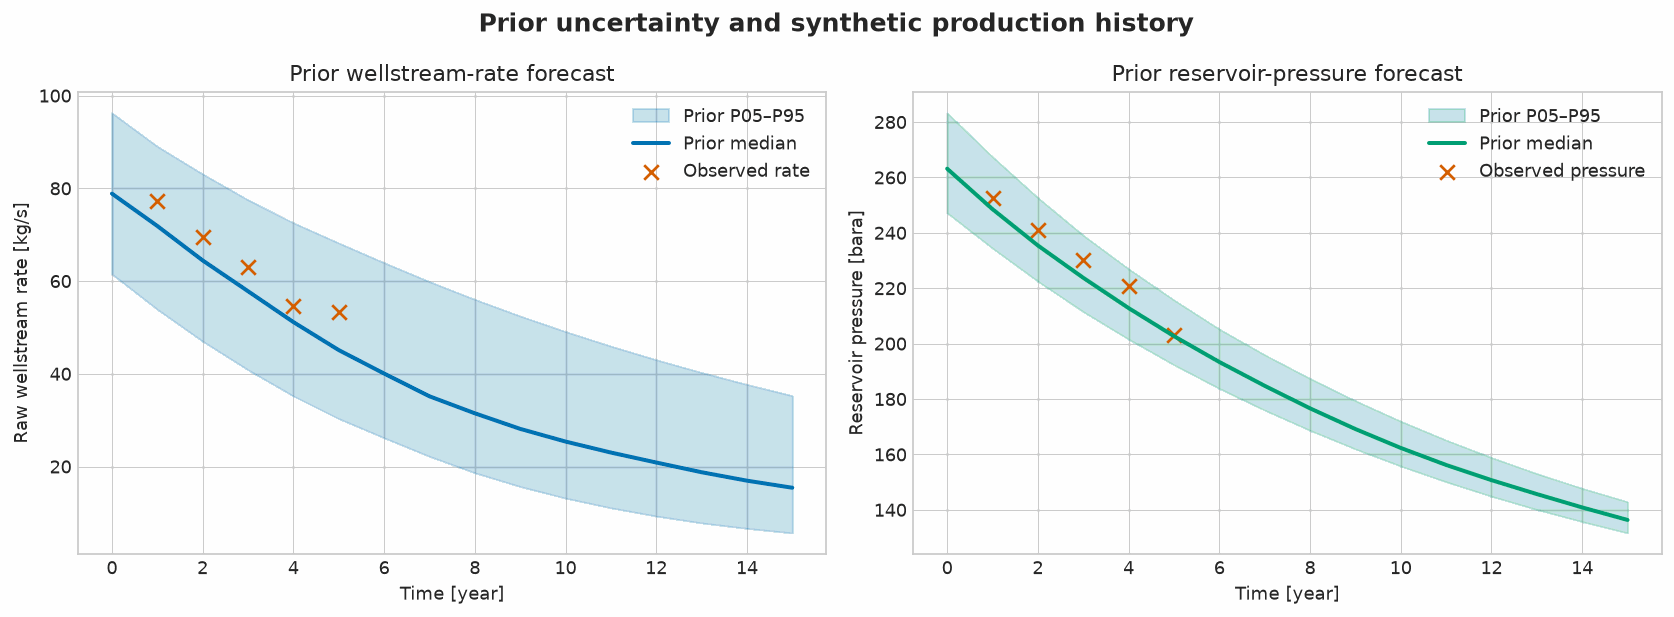

In [8]:
def summarize_ensemble(
    responses: pd.DataFrame,
    value_column: str,
) -> pd.DataFrame:
    grouped = responses.groupby("time_year")[value_column]
    summary = grouped.quantile([0.05, 0.50, 0.95]).unstack()
    summary.columns = ["p05", "p50", "p95"]
    return summary.reset_index()


prior_forecast = simulate_reservoir_ensemble(
    prior_parameters,
    FORECAST_YEARS,
)
prior_rate_summary = summarize_ensemble(
    prior_forecast,
    "wellstream_rate_kg_s",
)
prior_pressure_summary = summarize_ensemble(
    prior_forecast,
    "reservoir_pressure_bara",
)

figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].fill_between(
    prior_rate_summary["time_year"],
    prior_rate_summary["p05"],
    prior_rate_summary["p95"],
    color=COLORS["blue"],
    alpha=0.22,
    label="Prior P05–P95",
)
axes[0].plot(
    prior_rate_summary["time_year"],
    prior_rate_summary["p50"],
    color=COLORS["blue"],
    linewidth=2.2,
    label="Prior median",
)
axes[0].scatter(
    observations["time_year"],
    observations["wellstream_rate_kg_s"],
    color=COLORS["red"],
    marker="x",
    s=65,
    label="Observed rate",
)
axes[0].set_title("Prior wellstream-rate forecast")
axes[0].set_xlabel("Time [year]")
axes[0].set_ylabel("Raw wellstream rate [kg/s]")
axes[0].legend()

axes[1].fill_between(
    prior_pressure_summary["time_year"],
    prior_pressure_summary["p05"],
    prior_pressure_summary["p95"],
    color=COLORS["green"],
    alpha=0.22,
    label="Prior P05–P95",
)
axes[1].plot(
    prior_pressure_summary["time_year"],
    prior_pressure_summary["p50"],
    color=COLORS["green"],
    linewidth=2.2,
    label="Prior median",
)
axes[1].scatter(
    observations["time_year"],
    observations["reservoir_pressure_bara"],
    color=COLORS["red"],
    marker="x",
    s=65,
    label="Observed pressure",
)
axes[1].set_title("Prior reservoir-pressure forecast")
axes[1].set_xlabel("Time [year]")
axes[1].set_ylabel("Reservoir pressure [bara]")
axes[1].legend()

figure.suptitle(
    "Prior uncertainty and synthetic production history",
    fontsize=14,
    weight="bold",
)
figure.tight_layout()
plt.show()

**Interpretation.** The observations lie inside the broad prior ranges, so the ensemble is
suitable for an update. If all observations fell outside the ensemble, widening or
redesigning the prior would be more defensible than forcing a statistical update.

## 6. Transparent ensemble-smoother update

Let $X$ contain uncertain parameters and $Y$ contain predicted observations. A single
ensemble-smoother update is

$$
X^{a} = X^{f} + C_{XY}(C_{YY}+R)^{-1}(d+\epsilon-Y)
$$

Superscripts $f$ and $a$ mean forecast and analysed ensembles, $C_{XY}$ is the
parameter-response covariance, $C_{YY}$ is response covariance, $R$ is measurement-error
covariance, $d$ is the observation vector, and $\epsilon$ is a reproducible observation
perturbation. Units differ across columns, so the covariance matrices carry the required
compound units.

This educational implementation is one stochastic ES update. ERT supplies production
workflow controls, localization, restart handling, diagnostics, and ES-MDA options that
are outside this notebook's scope.

In [9]:
PARAMETER_COLUMNS = [
    "initial_rate_kg_s",
    "decline_per_year",
    "aquifer_support",
    "initial_pressure_bara",
]


def response_matrix(
    parameters: pd.DataFrame,
    years: np.ndarray,
) -> np.ndarray:
    responses = simulate_reservoir_ensemble(parameters, years)
    rate_matrix = responses.pivot(
        index="realization_id",
        columns="time_year",
        values="wellstream_rate_kg_s",
    )
    pressure_matrix = responses.pivot(
        index="realization_id",
        columns="time_year",
        values="reservoir_pressure_bara",
    )
    return np.hstack(
        [
            rate_matrix.to_numpy(),
            pressure_matrix.to_numpy(),
        ]
    )


predicted_observations = response_matrix(
    prior_parameters,
    HISTORY_YEARS,
)
observed_vector = np.concatenate(
    [
        observations["wellstream_rate_kg_s"].to_numpy(),
        observations["reservoir_pressure_bara"].to_numpy(),
    ]
)
observation_standard_deviation = np.concatenate(
    [
        np.full(len(HISTORY_YEARS), 2.0),
        np.full(len(HISTORY_YEARS), 2.5),
    ]
)

forecast_parameter_matrix = prior_parameters[PARAMETER_COLUMNS].to_numpy()
parameter_anomalies = forecast_parameter_matrix - forecast_parameter_matrix.mean(
    axis=0
)
response_anomalies = predicted_observations - predicted_observations.mean(axis=0)

covariance_xy = (
    parameter_anomalies.T @ response_anomalies
) / (ENSEMBLE_SIZE - 1)
covariance_yy = (
    response_anomalies.T @ response_anomalies
) / (ENSEMBLE_SIZE - 1)
measurement_covariance = np.diag(observation_standard_deviation**2)
kalman_gain = covariance_xy @ np.linalg.inv(
    covariance_yy + measurement_covariance
)

update_rng = np.random.default_rng(SEED + 2)
observation_perturbations = update_rng.normal(
    0.0,
    observation_standard_deviation,
    size=(ENSEMBLE_SIZE, observed_vector.size),
)
innovations = (
    observed_vector
    + observation_perturbations
    - predicted_observations
)
analysed_parameter_matrix = (
    forecast_parameter_matrix + innovations @ kalman_gain.T
)

posterior_parameters = prior_parameters[["realization_id"]].copy()
for column_index, parameter_name in enumerate(PARAMETER_COLUMNS):
    lower_bound, upper_bound = parameter_bounds[parameter_name]
    posterior_parameters[parameter_name] = np.clip(
        analysed_parameter_matrix[:, column_index],
        lower_bound,
        upper_bound,
    )

display(posterior_parameters.describe().round(3))

,realization_id,initial_rate_kg_s,decline_per_year,aquifer_support,initial_pressure_bara
count,80.000,80.000,80.000,80.000,80.000
mean,39.500,85.324,0.123,0.345,268.540
std,23.238,2.357,0.014,0.174,1.391
min,0.000,78.088,0.095,0.000,265.016
25%,19.750,83.781,0.114,0.213,267.698
50%,39.500,85.465,0.124,0.343,268.468
75%,59.250,86.725,0.134,0.489,269.618
max,79.000,90.340,0.153,0.664,271.497


## 7. Validate the history update

A history update is useful only if it reduces mismatch without producing impossible
parameters. The normalized root-mean-square error divides every residual by the relevant
measurement standard deviation. Values near one indicate residuals comparable with the
assumed observation uncertainty.

In [10]:
posterior_predictions = response_matrix(
    posterior_parameters,
    HISTORY_YEARS,
)

prior_normalized_rmse = np.sqrt(
    np.mean(
        (
            (
                predicted_observations.mean(axis=0)
                - observed_vector
            )
            / observation_standard_deviation
        )
        ** 2
    )
)
posterior_normalized_rmse = np.sqrt(
    np.mean(
        (
            (
                posterior_predictions.mean(axis=0)
                - observed_vector
            )
            / observation_standard_deviation
        )
        ** 2
    )
)

comparison_rows = []
for parameter_name in PARAMETER_COLUMNS:
    comparison_rows.append(
        {
            "parameter": parameter_name,
            "prior_mean": prior_parameters[parameter_name].mean(),
            "posterior_mean": posterior_parameters[parameter_name].mean(),
            "prior_std": prior_parameters[parameter_name].std(),
            "posterior_std": posterior_parameters[parameter_name].std(),
        }
    )

parameter_comparison = pd.DataFrame(comparison_rows)
display(parameter_comparison.round(4))
print(f"Prior normalized RMSE: {prior_normalized_rmse:.4f}")
print(f"Posterior normalized RMSE: {posterior_normalized_rmse:.4f}")

assert np.isfinite(posterior_parameters[PARAMETER_COLUMNS]).all().all()
assert posterior_normalized_rmse < prior_normalized_rmse
assert posterior_normalized_rmse < 1.5
for parameter_name, (lower_bound, upper_bound) in parameter_bounds.items():
    assert posterior_parameters[parameter_name].between(
        lower_bound,
        upper_bound,
    ).all()

Prior normalized RMSE: 2.2953
Posterior normalized RMSE: 0.8554


,parameter,prior_mean,posterior_mean,prior_std,posterior_std
0,initial_rate_kg_s,79.7965,85.3237,12.5787,2.3567
1,decline_per_year,0.1291,0.1235,0.0334,0.0140
2,aquifer_support,0.3249,0.3450,0.1908,0.1739
3,initial_pressure_bara,263.8869,268.5400,12.1021,1.3906


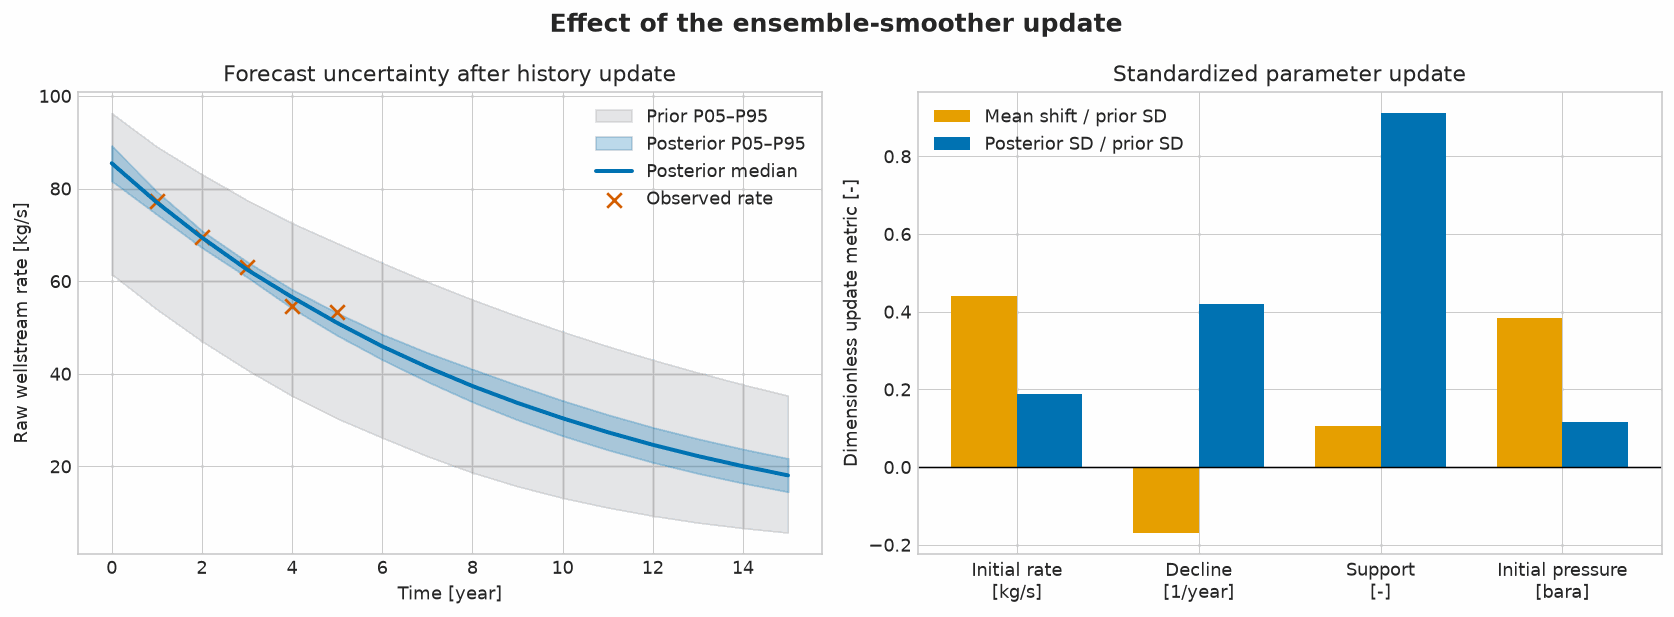

In [11]:
posterior_forecast = simulate_reservoir_ensemble(
    posterior_parameters,
    FORECAST_YEARS,
)
posterior_rate_summary = summarize_ensemble(
    posterior_forecast,
    "wellstream_rate_kg_s",
)

figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].fill_between(
    prior_rate_summary["time_year"],
    prior_rate_summary["p05"],
    prior_rate_summary["p95"],
    color=COLORS["gray"],
    alpha=0.18,
    label="Prior P05–P95",
)
axes[0].fill_between(
    posterior_rate_summary["time_year"],
    posterior_rate_summary["p05"],
    posterior_rate_summary["p95"],
    color=COLORS["blue"],
    alpha=0.26,
    label="Posterior P05–P95",
)
axes[0].plot(
    posterior_rate_summary["time_year"],
    posterior_rate_summary["p50"],
    color=COLORS["blue"],
    linewidth=2.2,
    label="Posterior median",
)
axes[0].scatter(
    observations["time_year"],
    observations["wellstream_rate_kg_s"],
    color=COLORS["red"],
    marker="x",
    s=65,
    label="Observed rate",
)
axes[0].set_title("Forecast uncertainty after history update")
axes[0].set_xlabel("Time [year]")
axes[0].set_ylabel("Raw wellstream rate [kg/s]")
axes[0].legend()

x_positions = np.arange(len(PARAMETER_COLUMNS))
standardized_mean_shift = (
    parameter_comparison["posterior_mean"]
    - parameter_comparison["prior_mean"]
) / parameter_comparison["prior_std"]
posterior_spread_ratio = (
    parameter_comparison["posterior_std"]
    / parameter_comparison["prior_std"]
)
axes[1].bar(
    x_positions - 0.18,
    standardized_mean_shift,
    width=0.36,
    color=COLORS["orange"],
    label="Mean shift / prior SD",
)
axes[1].bar(
    x_positions + 0.18,
    posterior_spread_ratio,
    width=0.36,
    color=COLORS["blue"],
    label="Posterior SD / prior SD",
)
axes[1].axhline(
    0.0,
    color="black",
    linewidth=0.8,
)
axes[1].set_xticks(x_positions)
axes[1].set_xticklabels(
    [
        "Initial rate\n[kg/s]",
        "Decline\n[1/year]",
        "Support\n[-]",
        "Initial pressure\n[bara]",
    ]
)
axes[1].set_title("Standardized parameter update")
axes[1].set_ylabel("Dimensionless update metric [-]")
axes[1].legend()

figure.suptitle(
    "Effect of the ensemble-smoother update",
    fontsize=14,
    weight="bold",
)
figure.tight_layout()
plt.show()

**Interpretation.** The update reduces normalized history mismatch and narrows the rate
forecast. In the parameter panel, a mean-shift magnitude near one means one prior standard
deviation, while a spread ratio below one means uncertainty reduction. In real studies,
identifiability, localization, multiple updates, geological plausibility, and prior design
need deeper review.

## 8. Build the real NeqSim facility model

The facility uses a Peng–Robinson equation of state because the synthetic wellstream is a
non-polar hydrocarbon-rich mixture at elevated pressure. The `classic` mixing rule is a
transparent baseline; water predictions near strict specifications may require a more
specialized association model and tuned interaction parameters.

The process workflow is:

1. create a compositional fluid and set total mass rate;
2. pass the wellstream through a choke from $90$ to $55\ \mathrm{bara}$;
3. cool to $303.15\ \mathrm{K}$;
4. perform equilibrium gas, oil, and aqueous separation;
5. compress separator gas to $120\ \mathrm{bara}$ at $78\%$ isentropic efficiency.

For the separator,

$$
\dot{m}_{feed} = \dot{m}_{gas} + \dot{m}_{oil} + \dot{m}_{water}
$$

where every mass flow $\dot{m}$ is in $\mathrm{kg/s}$. The residual is checked for every
calibrated rate.

In [12]:
from neqsim.process import (
    compressor,
    cooler,
    newProcess,
    separator3phase,
    stream,
    valve,
)
from neqsim.thermo import fluid

WELLSTREAM_COMPOSITION = {
    "nitrogen": 0.010,
    "CO2": 0.020,
    "methane": 0.620,
    "ethane": 0.100,
    "propane": 0.080,
    "n-butane": 0.060,
    "n-pentane": 0.040,
    "n-hexane": 0.025,
    "n-heptane": 0.025,
    "water": 0.020,
}

composition_sum = sum(WELLSTREAM_COMPOSITION.values())
assert np.isclose(composition_sum, 1.0, atol=1.0e-12)
print(f"Wellstream mole-fraction sum: {composition_sum:.12f}")

Wellstream mole-fraction sum: 1.000000000000


In [13]:
def build_wellstream(total_rate_kg_s: float):
    wellstream_fluid = fluid(
        "pr",
        temperature=333.15,
        pressure=90.0,
    )

    for component_name, mole_fraction in WELLSTREAM_COMPOSITION.items():
        wellstream_fluid.addComponent(
            component_name,
            mole_fraction,
        )

    wellstream_fluid.setMixingRule("classic")
    wellstream_fluid.setMultiPhaseCheck(True)
    wellstream_fluid.setTotalFlowRate(
        float(total_rate_kg_s),
        "kg/sec",
    )
    return wellstream_fluid


reference_fluid = build_wellstream(75.0)
print(
    "Reference fluid:",
    f"{reference_fluid.getNumberOfComponents()} components,",
    "Peng–Robinson EOS",
)

Reference fluid: 10 components, Peng–Robinson EOS


The process objects are connected explicitly. `Stream` carries a thermodynamic system,
`ThrottlingValve` performs an isenthalpic pressure change, `Cooler` imposes the separator
inlet temperature, `ThreePhaseSeparator` creates phase-product streams, and `Compressor`
calculates the gas discharge state and shaft power. `ProcessSystem.run()` executes them in
connection order.

In [14]:
def run_neqsim_facility(total_rate_kg_s: float) -> dict[str, float]:
    process_model = newProcess(
        f"facility at {total_rate_kg_s:.1f} kg/s"
    )
    feed_fluid = build_wellstream(total_rate_kg_s)

    feed_stream = stream(
        "raw wellstream",
        feed_fluid,
        process=process_model,
    )
    inlet_choke = valve(
        "inlet choke",
        feed_stream,
        p=55.0,
        process=process_model,
    )
    inlet_cooler = cooler(
        "inlet cooler",
        inlet_choke.getOutletStream(),
        process=process_model,
    )
    inlet_cooler.setOutTemperature(303.15)

    inlet_separator = separator3phase(
        "inlet three-phase separator",
        inlet_cooler.getOutletStream(),
        process=process_model,
    )
    export_compressor = compressor(
        "export gas compressor",
        inlet_separator.getGasOutStream(),
        pres=120.0,
        process=process_model,
    )
    export_compressor.setIsentropicEfficiency(0.78)

    process_model.run()

    feed_mass_rate = feed_stream.getFlowRate("kg/sec")
    gas_mass_rate = inlet_separator.getGasOutStream().getFlowRate("kg/sec")
    oil_mass_rate = inlet_separator.getOilOutStream().getFlowRate("kg/sec")
    water_mass_rate = inlet_separator.getWaterOutStream().getFlowRate("kg/sec")
    outlet_mass_rate = gas_mass_rate + oil_mass_rate + water_mass_rate

    return {
        "feed_rate_kg_s": feed_mass_rate,
        "gas_rate_kg_s": gas_mass_rate,
        "oil_rate_kg_s": oil_mass_rate,
        "water_rate_kg_s": water_mass_rate,
        "compressor_power_mw": export_compressor.getPower() / 1.0e6,
        "compressor_outlet_temperature_k": (
            export_compressor.getOutletStream().getTemperature()
        ),
        "mass_residual_kg_s": feed_mass_rate - outlet_mass_rate,
    }


reference_process_result = run_neqsim_facility(75.0)
display(pd.DataFrame([reference_process_result]).round(6))

,feed_rate_kg_s,gas_rate_kg_s,oil_rate_kg_s,water_rate_kg_s,compressor_power_mw,compressor_outlet_temperature_k,mass_residual_kg_s
0,75.0,41.015414,33.083403,0.901183,4.255946,367.751547,0.0


## 9. Process schematic and reference-case checks

This second workflow visual emphasizes process topology rather than software integration.
Pressure and temperature specifications are shown at the equipment where they are applied.

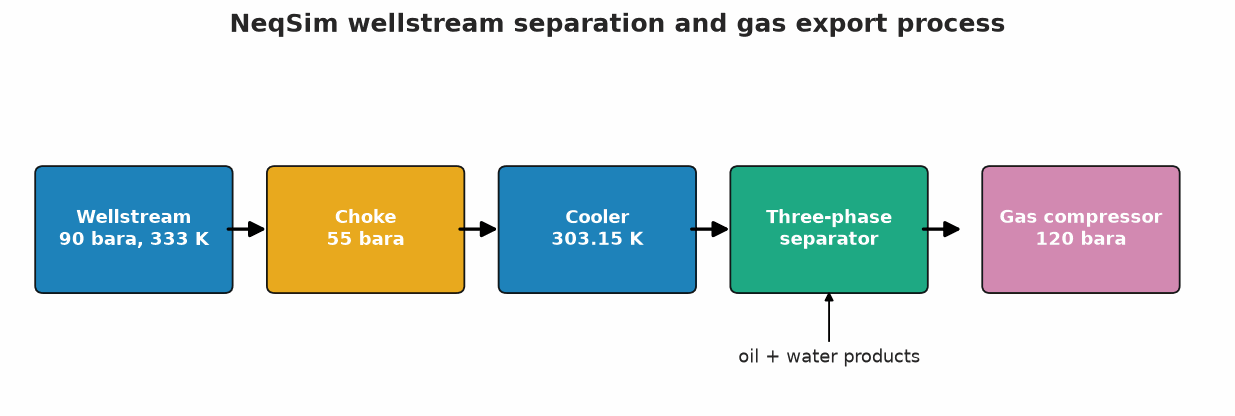

In [15]:
figure, axis = plt.subplots(figsize=(12, 3.6))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 4.0)
axis.axis("off")

process_nodes = [
    (0.3, "Wellstream\n90 bara, 333 K", COLORS["blue"]),
    (2.6, "Choke\n55 bara", COLORS["orange"]),
    (4.9, "Cooler\n303.15 K", COLORS["blue"]),
    (7.2, "Three-phase\nseparator", COLORS["green"]),
    (9.7, "Gas compressor\n120 bara", COLORS["purple"]),
]

for x_position, label, color in process_nodes:
    box = FancyBboxPatch(
        (x_position, 1.3),
        1.8,
        1.25,
        boxstyle="round,pad=0.08",
        facecolor=color,
        edgecolor="black",
        alpha=0.88,
    )
    axis.add_patch(box)
    axis.text(
        x_position + 0.9,
        1.93,
        label,
        ha="center",
        va="center",
        color="white",
        fontsize=10,
        weight="bold",
    )

for start_x in [2.1, 4.4, 6.7, 9.0]:
    axis.add_patch(
        FancyArrowPatch(
            (start_x, 1.93),
            (start_x + 0.45, 1.93),
            arrowstyle="-|>",
            mutation_scale=18,
            linewidth=1.8,
            color="black",
        )
    )

axis.annotate(
    "oil + water products",
    xy=(8.1, 1.28),
    xytext=(8.1, 0.45),
    ha="center",
    arrowprops={
        "arrowstyle": "-|>",
        "color": "black",
    },
)
axis.set_title(
    "NeqSim wellstream separation and gas export process",
    fontsize=14,
    weight="bold",
)
plt.show()

In [16]:
reference_feed_rate = reference_process_result["feed_rate_kg_s"]
reference_mass_residual = reference_process_result["mass_residual_kg_s"]
relative_mass_residual = abs(reference_mass_residual) / reference_feed_rate

assert reference_process_result["gas_rate_kg_s"] > 0.0
assert reference_process_result["oil_rate_kg_s"] > 0.0
assert reference_process_result["water_rate_kg_s"] > 0.0
assert reference_process_result["compressor_power_mw"] > 0.0
assert reference_process_result["compressor_outlet_temperature_k"] > 303.15
assert relative_mass_residual < 1.0e-9

print(f"Relative separator mass residual: {relative_mass_residual:.3e}")
print(
    "Compressor outlet temperature:",
    f"{reference_process_result['compressor_outlet_temperature_k']:.3f} K",
)

Relative separator mass residual: 9.095e-15
Compressor outlet temperature: 367.752 K


**Interpretation.** The reference wellstream forms all three expected phases. Compression
raises gas temperature and requires positive power. The separator closes mass to numerical
precision, so later capacity calculations are based on a consistent material split.

## 10. Calibrate a facility response surface with NeqSim

Running NeqSim for every realization and every year is possible but unnecessary for this
fixed-composition, fixed-pressure teaching case. We run seven independent NeqSim process
calculations, verify their trends and balances, and interpolate those released-model
results. This is a response surface over total mass rate only; it must be recalibrated if
composition, separator conditions, or compressor efficiency change.

In [17]:
calibration_rates_kg_s = np.linspace(35.0, 110.0, 7)
facility_calibration = pd.DataFrame(
    [
        run_neqsim_facility(rate_kg_s)
        for rate_kg_s in calibration_rates_kg_s
    ]
)

numeric_columns = facility_calibration.select_dtypes(include=[np.number]).columns
assert np.isfinite(facility_calibration[numeric_columns]).all().all()
assert facility_calibration["compressor_power_mw"].is_monotonic_increasing
assert facility_calibration["gas_rate_kg_s"].is_monotonic_increasing
assert facility_calibration["oil_rate_kg_s"].is_monotonic_increasing
assert facility_calibration["water_rate_kg_s"].is_monotonic_increasing
assert facility_calibration["mass_residual_kg_s"].abs().max() < 1.0e-8

display(facility_calibration.round(6))

,feed_rate_kg_s,gas_rate_kg_s,oil_rate_kg_s,water_rate_kg_s,compressor_power_mw,compressor_outlet_temperature_k,mass_residual_kg_s
0,35.0,19.140526,15.438922,0.420552,1.986108,367.751547,0.0
1,47.5,25.976429,20.952822,0.570749,2.695432,367.751547,0.0
2,60.0,32.812331,26.466723,0.720946,3.404757,367.751547,0.0
3,72.5,39.648233,31.980623,0.871143,4.114081,367.751547,0.0
4,85.0,46.484135,37.494524,1.021341,4.823405,367.751547,0.0
5,97.5,53.320038,43.008425,1.171538,5.532729,367.751547,0.0
6,110.0,60.155940,48.522325,1.321735,6.242054,367.751547,0.0


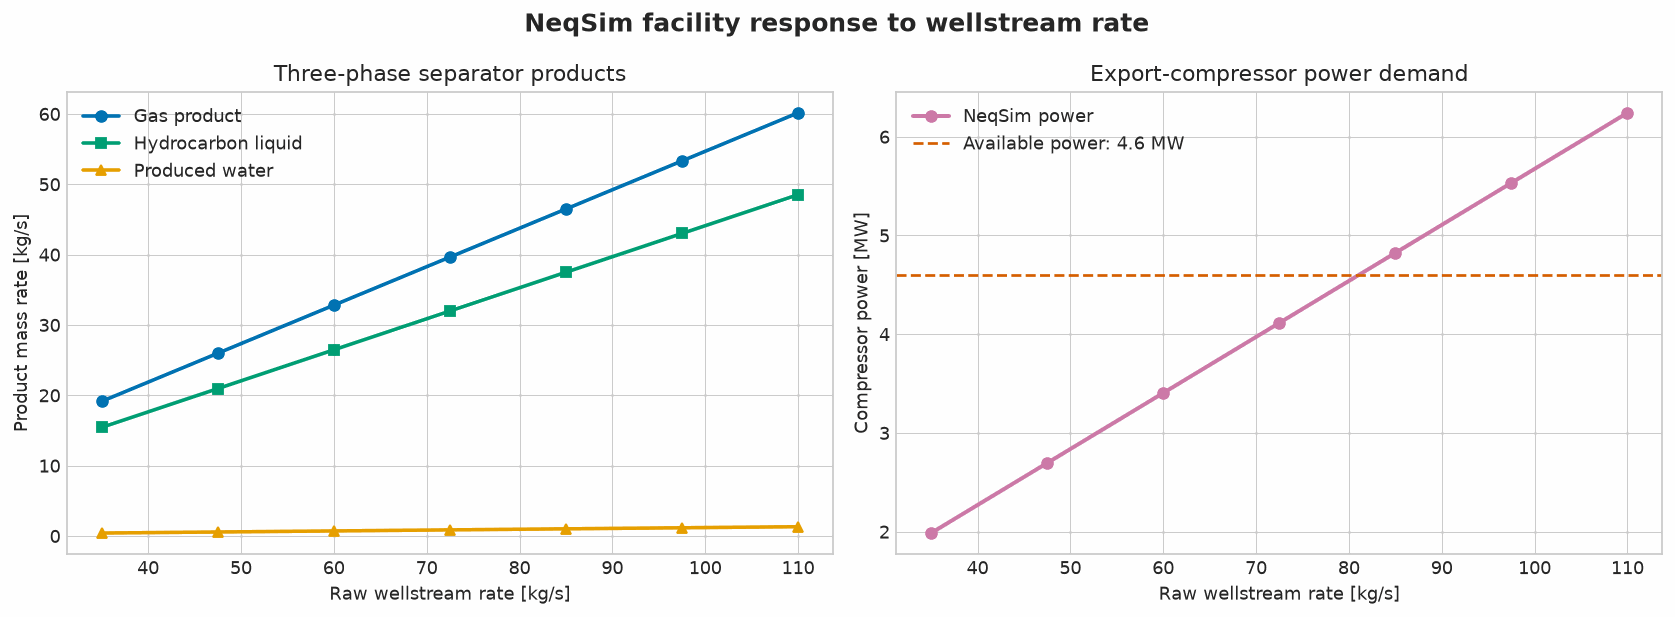

In [18]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].plot(
    facility_calibration["feed_rate_kg_s"],
    facility_calibration["gas_rate_kg_s"],
    "o-",
    color=COLORS["blue"],
    linewidth=2.0,
    label="Gas product",
)
axes[0].plot(
    facility_calibration["feed_rate_kg_s"],
    facility_calibration["oil_rate_kg_s"],
    "s-",
    color=COLORS["green"],
    linewidth=2.0,
    label="Hydrocarbon liquid",
)
axes[0].plot(
    facility_calibration["feed_rate_kg_s"],
    facility_calibration["water_rate_kg_s"],
    "^-",
    color=COLORS["orange"],
    linewidth=2.0,
    label="Produced water",
)
axes[0].set_title("Three-phase separator products")
axes[0].set_xlabel("Raw wellstream rate [kg/s]")
axes[0].set_ylabel("Product mass rate [kg/s]")
axes[0].legend()

axes[1].plot(
    facility_calibration["feed_rate_kg_s"],
    facility_calibration["compressor_power_mw"],
    "o-",
    color=COLORS["purple"],
    linewidth=2.2,
    label="NeqSim power",
)
axes[1].axhline(
    4.6,
    color=COLORS["red"],
    linestyle="--",
    label="Available power: 4.6 MW",
)
axes[1].set_title("Export-compressor power demand")
axes[1].set_xlabel("Raw wellstream rate [kg/s]")
axes[1].set_ylabel("Compressor power [MW]")
axes[1].legend()

figure.suptitle(
    "NeqSim facility response to wellstream rate",
    fontsize=14,
    weight="bold",
)
figure.tight_layout()
plt.show()

**Interpretation.** Product rates and compressor power increase smoothly with feed rate.
The phase split is nearly constant because composition, pressure, and temperature are held
fixed. The power line crosses the illustrative $4.6\ \mathrm{MW}$ availability within the
calibration interval, so ensemble rate uncertainty creates a measurable bottleneck risk.

## 11. Transfer the posterior ensemble into the facility model

Interpolation is restricted to the validated NeqSim calibration range. Values beyond the
range are not silently extrapolated. Instead, the unconstrained reservoir rate is clipped
to the maximum calibrated rate before interpolation and is separately flagged. A project
model should add NeqSim points until all relevant realizations lie inside its domain.

In [19]:
FACILITY_LIMITS = {
    "compressor_power_mw": 4.6,
    "gas_export_kg_s": 50.0,
    "liquid_handling_kg_s": 42.0,
}


def interpolate_facility_response(
    feed_rate_kg_s: np.ndarray,
    response_column: str,
) -> np.ndarray:
    minimum_rate = facility_calibration["feed_rate_kg_s"].min()
    maximum_rate = facility_calibration["feed_rate_kg_s"].max()
    bounded_rate = np.clip(
        np.asarray(feed_rate_kg_s, dtype=float),
        minimum_rate,
        maximum_rate,
    )
    return np.interp(
        bounded_rate,
        facility_calibration["feed_rate_kg_s"],
        facility_calibration[response_column],
    )


integrated_forecast = posterior_forecast.copy()
integrated_forecast["gas_rate_kg_s"] = interpolate_facility_response(
    integrated_forecast["wellstream_rate_kg_s"],
    "gas_rate_kg_s",
)
integrated_forecast["oil_rate_kg_s"] = interpolate_facility_response(
    integrated_forecast["wellstream_rate_kg_s"],
    "oil_rate_kg_s",
)
integrated_forecast["water_rate_kg_s"] = interpolate_facility_response(
    integrated_forecast["wellstream_rate_kg_s"],
    "water_rate_kg_s",
)
integrated_forecast["compressor_power_mw"] = interpolate_facility_response(
    integrated_forecast["wellstream_rate_kg_s"],
    "compressor_power_mw",
)
integrated_forecast["liquid_rate_kg_s"] = (
    integrated_forecast["oil_rate_kg_s"]
    + integrated_forecast["water_rate_kg_s"]
)
integrated_forecast["outside_calibration"] = (
    integrated_forecast["wellstream_rate_kg_s"]
    > facility_calibration["feed_rate_kg_s"].max()
)
integrated_forecast["power_limited"] = (
    integrated_forecast["compressor_power_mw"]
    > FACILITY_LIMITS["compressor_power_mw"]
)
integrated_forecast["gas_limited"] = (
    integrated_forecast["gas_rate_kg_s"]
    > FACILITY_LIMITS["gas_export_kg_s"]
)
integrated_forecast["liquid_limited"] = (
    integrated_forecast["liquid_rate_kg_s"]
    > FACILITY_LIMITS["liquid_handling_kg_s"]
)
integrated_forecast["any_bottleneck"] = integrated_forecast[
    [
        "power_limited",
        "gas_limited",
        "liquid_limited",
    ]
].any(axis=1)

bottleneck_probability = (
    integrated_forecast.groupby("time_year")[
        [
            "power_limited",
            "gas_limited",
            "liquid_limited",
            "any_bottleneck",
            "outside_calibration",
        ]
    ]
    .mean()
    .reset_index()
)

display(bottleneck_probability.round(3))

,time_year,power_limited,gas_limited,liquid_limited,any_bottleneck,outside_calibration
0,0.0,0.95,0.0,0.0,0.95,0.0
1,1.0,0.00,0.0,0.0,0.00,0.0
2,2.0,0.00,0.0,0.0,0.00,0.0
3,3.0,0.00,0.0,0.0,0.00,0.0
4,4.0,0.00,0.0,0.0,0.00,0.0
5,5.0,0.00,0.0,0.0,0.00,0.0
6,6.0,0.00,0.0,0.0,0.00,0.0
7,7.0,0.00,0.0,0.0,0.00,0.0
8,8.0,0.00,0.0,0.0,0.00,0.0
9,9.0,0.00,0.0,0.0,0.00,0.0


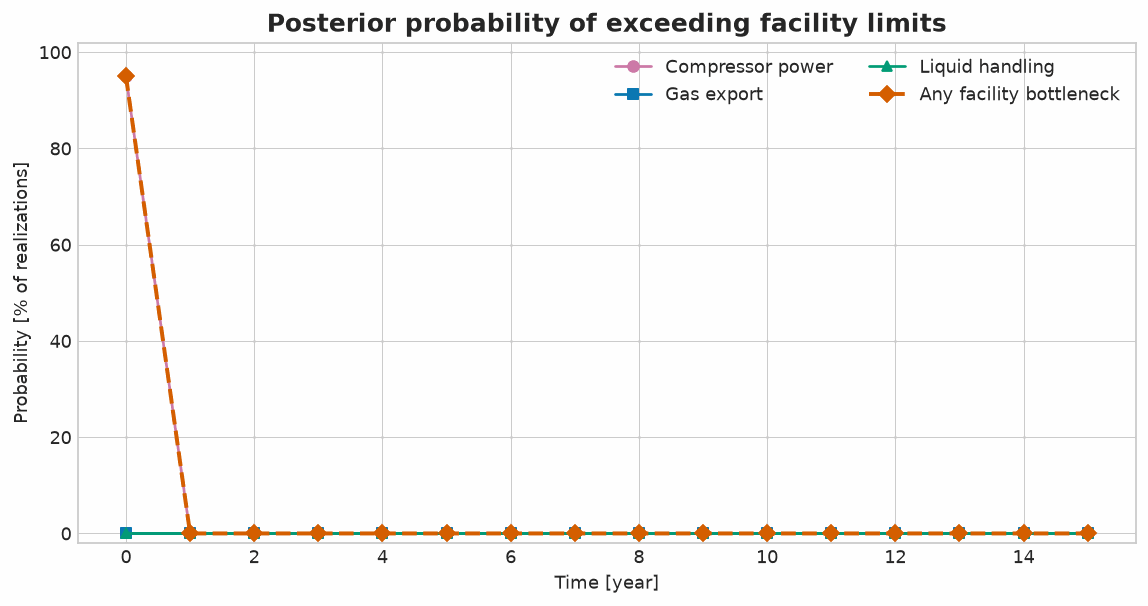

In [20]:
figure, axis = plt.subplots(figsize=(10.5, 5.0))

axis.plot(
    bottleneck_probability["time_year"],
    100.0 * bottleneck_probability["power_limited"],
    "o-",
    color=COLORS["purple"],
    label="Compressor power",
)
axis.plot(
    bottleneck_probability["time_year"],
    100.0 * bottleneck_probability["gas_limited"],
    "s-",
    color=COLORS["blue"],
    label="Gas export",
)
axis.plot(
    bottleneck_probability["time_year"],
    100.0 * bottleneck_probability["liquid_limited"],
    "^-",
    color=COLORS["green"],
    label="Liquid handling",
)
axis.plot(
    bottleneck_probability["time_year"],
    100.0 * bottleneck_probability["any_bottleneck"],
    "D--",
    color=COLORS["red"],
    linewidth=2.2,
    label="Any facility bottleneck",
)
axis.set_title(
    "Posterior probability of exceeding facility limits",
    fontsize=14,
    weight="bold",
)
axis.set_xlabel("Time [year]")
axis.set_ylabel("Probability [% of realizations]")
axis.set_ylim(-2.0, 102.0)
axis.legend(ncol=2)
plt.show()

**Interpretation.** Bottleneck probability is highest during the early high-rate years and
declines as the reservoir depletes. The separate curves identify the active constraint.
The `outside_calibration` column is a model-validity diagnostic, not a facility limit; any
nonzero value calls for additional NeqSim calibration points before a decision is made.

## 12. End-to-end constrained-production application

For a simple operational response, determine the largest feed rate satisfying every
interpolated facility limit. The accepted rate is then the smaller of the reservoir
deliverability and facility capacity. This is a screening workflow, not an optimizer:
it does not model wells, gathering pressure, compressor maps, recycle, uptime, or economic
objectives.

In [21]:
dense_rate_grid = np.linspace(
    facility_calibration["feed_rate_kg_s"].min(),
    facility_calibration["feed_rate_kg_s"].max(),
    500,
)
dense_power = interpolate_facility_response(
    dense_rate_grid,
    "compressor_power_mw",
)
dense_gas = interpolate_facility_response(
    dense_rate_grid,
    "gas_rate_kg_s",
)
dense_oil = interpolate_facility_response(
    dense_rate_grid,
    "oil_rate_kg_s",
)
dense_water = interpolate_facility_response(
    dense_rate_grid,
    "water_rate_kg_s",
)

feasible_grid = (
    (dense_power <= FACILITY_LIMITS["compressor_power_mw"])
    & (dense_gas <= FACILITY_LIMITS["gas_export_kg_s"])
    & (
        dense_oil + dense_water
        <= FACILITY_LIMITS["liquid_handling_kg_s"]
    )
)
assert feasible_grid.any()

facility_capacity_kg_s = dense_rate_grid[feasible_grid].max()
integrated_forecast["accepted_rate_kg_s"] = np.minimum(
    integrated_forecast["wellstream_rate_kg_s"],
    facility_capacity_kg_s,
)
integrated_forecast["curtailed_rate_kg_s"] = (
    integrated_forecast["wellstream_rate_kg_s"]
    - integrated_forecast["accepted_rate_kg_s"]
)

accepted_rate_summary = summarize_ensemble(
    integrated_forecast,
    "accepted_rate_kg_s",
)
curtailed_rate_summary = summarize_ensemble(
    integrated_forecast,
    "curtailed_rate_kg_s",
)

print(f"Integrated facility capacity: {facility_capacity_kg_s:.3f} kg/s")

Integrated facility capacity: 80.992 kg/s


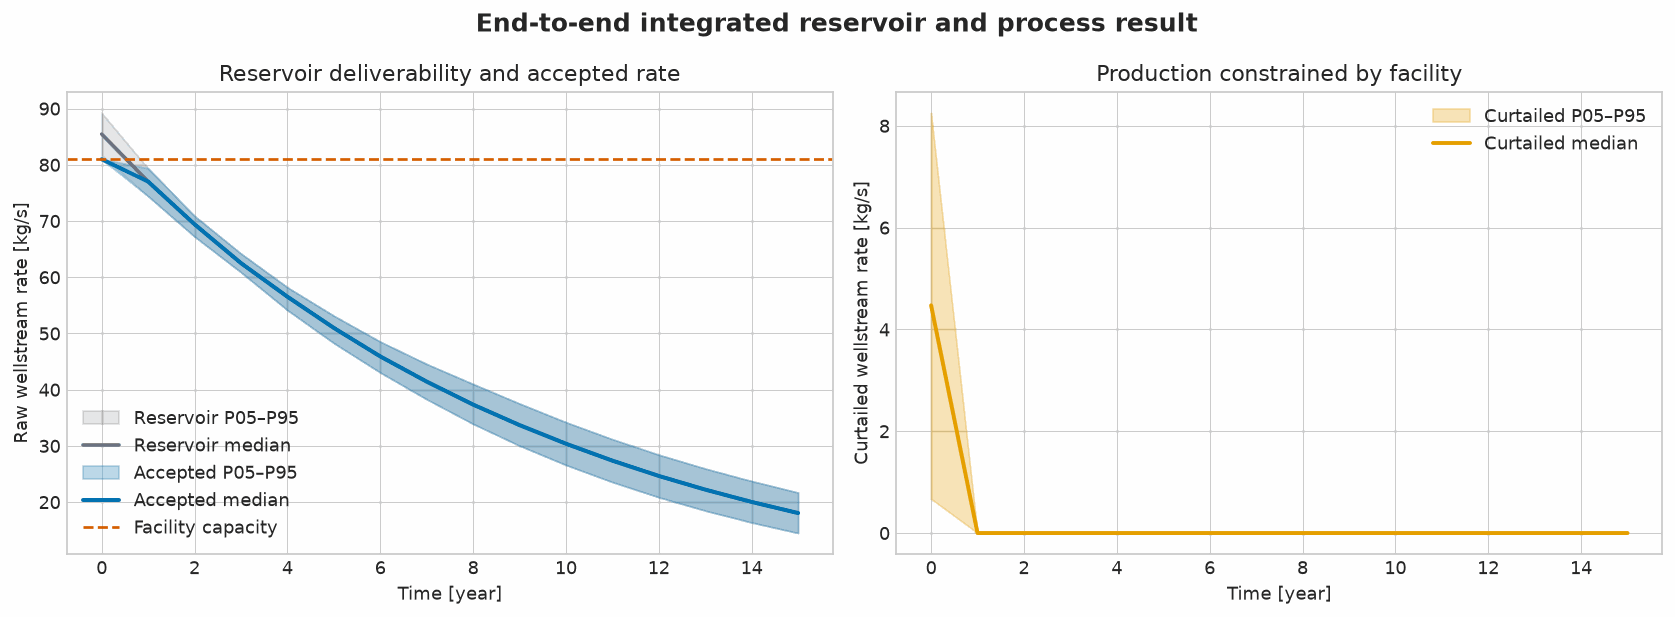

In [22]:
figure, axes = plt.subplots(1, 2, figsize=(13, 4.8))

axes[0].fill_between(
    posterior_rate_summary["time_year"],
    posterior_rate_summary["p05"],
    posterior_rate_summary["p95"],
    color=COLORS["gray"],
    alpha=0.20,
    label="Reservoir P05–P95",
)
axes[0].plot(
    posterior_rate_summary["time_year"],
    posterior_rate_summary["p50"],
    color=COLORS["gray"],
    linewidth=2.0,
    label="Reservoir median",
)
axes[0].fill_between(
    accepted_rate_summary["time_year"],
    accepted_rate_summary["p05"],
    accepted_rate_summary["p95"],
    color=COLORS["blue"],
    alpha=0.26,
    label="Accepted P05–P95",
)
axes[0].plot(
    accepted_rate_summary["time_year"],
    accepted_rate_summary["p50"],
    color=COLORS["blue"],
    linewidth=2.2,
    label="Accepted median",
)
axes[0].axhline(
    facility_capacity_kg_s,
    color=COLORS["red"],
    linestyle="--",
    label="Facility capacity",
)
axes[0].set_title("Reservoir deliverability and accepted rate")
axes[0].set_xlabel("Time [year]")
axes[0].set_ylabel("Raw wellstream rate [kg/s]")
axes[0].legend()

axes[1].fill_between(
    curtailed_rate_summary["time_year"],
    curtailed_rate_summary["p05"],
    curtailed_rate_summary["p95"],
    color=COLORS["orange"],
    alpha=0.28,
    label="Curtailed P05–P95",
)
axes[1].plot(
    curtailed_rate_summary["time_year"],
    curtailed_rate_summary["p50"],
    color=COLORS["orange"],
    linewidth=2.2,
    label="Curtailed median",
)
axes[1].set_title("Production constrained by facility")
axes[1].set_xlabel("Time [year]")
axes[1].set_ylabel("Curtailed wellstream rate [kg/s]")
axes[1].legend()

figure.suptitle(
    "End-to-end integrated reservoir and process result",
    fontsize=14,
    weight="bold",
)
figure.tight_layout()
plt.show()

**Engineering conclusion.** The facility clips only the high-rate portion of the ensemble,
so early debottlenecking has value while late-life capacity expansion does not. A real
decision would compare expansion cost and schedule with the distribution of recovered
production, not only the median line.

## 13. Facility sensitivity scenarios

Capacity decisions are uncertain on both the reservoir and facility sides. The scenario
screen varies available compressor power while retaining gas-export and liquid-handling
limits. The result is cumulative curtailed mass over the 15 one-year intervals:

$$
M_{curtailed} = \sum_t \dot{m}_{curtailed,t}\Delta t
$$

where $M_{curtailed}$ is in million tonnes, $\dot{m}_{curtailed,t}$ is in
$\mathrm{kg/s}$, and $\Delta t$ is one year in seconds.

In [23]:
SECONDS_PER_YEAR = 365.25 * 24.0 * 3600.0
power_scenarios_mw = [4.0, 4.6, 5.2, 5.8]
scenario_rows = []

for available_power_mw in power_scenarios_mw:
    scenario_feasible = (
        (dense_power <= available_power_mw)
        & (dense_gas <= FACILITY_LIMITS["gas_export_kg_s"])
        & (
            dense_oil + dense_water
            <= FACILITY_LIMITS["liquid_handling_kg_s"]
        )
    )
    scenario_capacity = dense_rate_grid[scenario_feasible].max()
    scenario_curtailed = np.maximum(
        integrated_forecast["wellstream_rate_kg_s"] - scenario_capacity,
        0.0,
    )
    cumulative_curtailed_mt = (
        scenario_curtailed.groupby(integrated_forecast["realization_id"])
        .sum()
        * SECONDS_PER_YEAR
        / 1.0e9
    )
    scenario_rows.append(
        {
            "available_power_mw": available_power_mw,
            "facility_capacity_kg_s": scenario_capacity,
            "p50_curtailed_mt": cumulative_curtailed_mt.median(),
            "p90_curtailed_mt": cumulative_curtailed_mt.quantile(0.90),
        }
    )

scenario_results = pd.DataFrame(scenario_rows)
display(scenario_results.round(4))

assert scenario_results["facility_capacity_kg_s"].is_monotonic_increasing
assert scenario_results["p50_curtailed_mt"].is_monotonic_decreasing

,available_power_mw,facility_capacity_kg_s,p50_curtailed_mt,p90_curtailed_mt
0,4.0,70.4709,0.6816,0.8478
1,4.6,80.9920,0.1411,0.2324
2,5.2,91.3627,0.0000,0.0000
3,5.8,91.3627,0.0000,0.0000


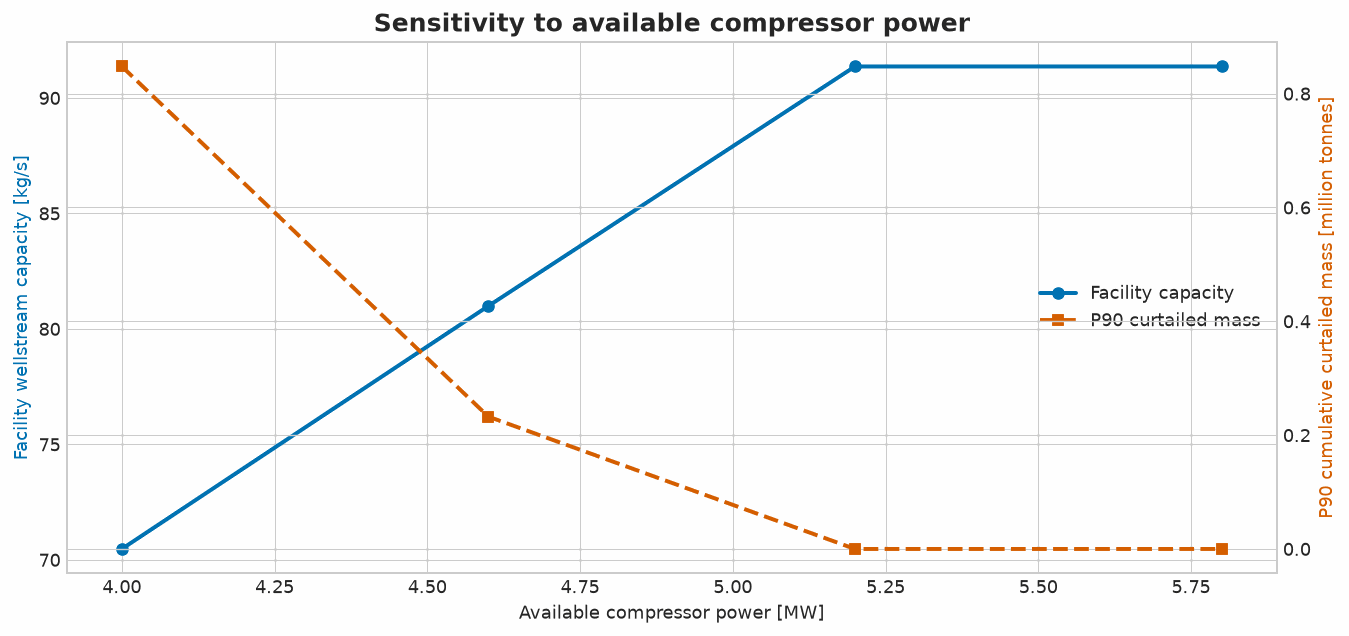

In [24]:
figure, axis_left = plt.subplots(figsize=(10.5, 5.0))
axis_right = axis_left.twinx()

capacity_line = axis_left.plot(
    scenario_results["available_power_mw"],
    scenario_results["facility_capacity_kg_s"],
    "o-",
    color=COLORS["blue"],
    linewidth=2.2,
    label="Facility capacity",
)
curtailment_line = axis_right.plot(
    scenario_results["available_power_mw"],
    scenario_results["p90_curtailed_mt"],
    "s--",
    color=COLORS["red"],
    linewidth=2.2,
    label="P90 curtailed mass",
)

axis_left.set_title(
    "Sensitivity to available compressor power",
    fontsize=14,
    weight="bold",
)
axis_left.set_xlabel("Available compressor power [MW]")
axis_left.set_ylabel(
    "Facility wellstream capacity [kg/s]",
    color=COLORS["blue"],
)
axis_right.set_ylabel(
    "P90 cumulative curtailed mass [million tonnes]",
    color=COLORS["red"],
)

combined_lines = capacity_line + curtailment_line
axis_left.legend(
    combined_lines,
    [line.get_label() for line in combined_lines],
    loc="center right",
)
figure.tight_layout()
plt.show()

**Interpretation.** More available compressor power increases capacity and reduces
curtailment until another limit becomes active. A plateau is therefore meaningful: it
indicates that extra driver power alone no longer debottlenecks the integrated system.

## 14. ERT-compatible files and forward-model reuse

The original notebook tried to load `reservoir_model.ert` through a nonexistent Python
function. In practice, ERT configuration points to parameter files and a forward-model
command. The next cell exports one row per realization and the predicted response table.
A production forward model would read one realization's parameters, run the reservoir
simulator, call the reusable NeqSim facility function, and write responses using the names
expected by the ERT configuration.

In [25]:
export_directory = Path("ensemble_exports")
export_directory.mkdir(exist_ok=True)

parameter_export_path = export_directory / "posterior_parameters.csv"
response_export_path = export_directory / "integrated_responses.csv"
schema_export_path = export_directory / "exchange_schema.txt"

posterior_parameters.to_csv(
    parameter_export_path,
    index=False,
)
integrated_forecast.to_csv(
    response_export_path,
    index=False,
)
schema_export_path.write_text(
    "\n".join(
        f"{field_name}: {unit}"
        for field_name, unit in exchange_schema.items()
    ),
    encoding="utf-8",
)

export_inventory = pd.DataFrame(
    {
        "file": [
            parameter_export_path.as_posix(),
            response_export_path.as_posix(),
            schema_export_path.as_posix(),
        ],
        "purpose": [
            "Analysed ensemble parameters",
            "Reservoir and NeqSim facility responses",
            "Field names and engineering units",
        ],
    }
)
display(export_inventory)

,file,purpose
0,ensemble_exports/posterior_parameters.csv,Analysed ensemble parameters
1,ensemble_exports/integrated_responses.csv,Reservoir and NeqSim facility responses
2,ensemble_exports/exchange_schema.txt,Field names and engineering units


In [26]:
parameter_round_trip = pd.read_csv(parameter_export_path)
response_round_trip = pd.read_csv(response_export_path)

assert len(parameter_round_trip) == ENSEMBLE_SIZE
assert len(response_round_trip) == ENSEMBLE_SIZE * len(FORECAST_YEARS)
assert set(exchange_schema).issubset(response_round_trip.columns)
assert parameter_round_trip[PARAMETER_COLUMNS].notna().all().all()
assert response_round_trip[
    [
        "reservoir_pressure_bara",
        "wellstream_rate_kg_s",
        "compressor_power_mw",
    ]
].notna().all().all()

print("Parameter and response files passed round-trip validation.")

Parameter and response files passed round-trip validation.


## 15. Final validation checks

The acceptance checks cover reproducibility, finite values, bounds, history improvement,
separator closure, expected rate and power trends, facility-domain coverage, and
constrained-rate logic. A failed assertion indicates either an implementation error or an
assumption that no longer holds after inputs are changed.

In [27]:
validation_checks = {
    "composition sums to one": np.isclose(
        composition_sum,
        1.0,
        atol=1.0e-12,
    ),
    "posterior history fit improves": (
        posterior_normalized_rmse < prior_normalized_rmse
    ),
    "posterior history fit is plausible": (
        posterior_normalized_rmse < 1.5
    ),
    "separator mass closes": (
        facility_calibration["mass_residual_kg_s"].abs().max() < 1.0e-8
    ),
    "gas product increases with feed": (
        facility_calibration["gas_rate_kg_s"].is_monotonic_increasing
    ),
    "liquid products increase with feed": (
        facility_calibration["oil_rate_kg_s"].is_monotonic_increasing
        and facility_calibration["water_rate_kg_s"].is_monotonic_increasing
    ),
    "compressor power increases with feed": (
        facility_calibration["compressor_power_mw"].is_monotonic_increasing
    ),
    "all ensemble results are finite": np.isfinite(
        integrated_forecast[
            [
                "reservoir_pressure_bara",
                "wellstream_rate_kg_s",
                "compressor_power_mw",
                "accepted_rate_kg_s",
            ]
        ]
    ).all().all(),
    "accepted rate never exceeds deliverability": (
        integrated_forecast["accepted_rate_kg_s"]
        <= integrated_forecast["wellstream_rate_kg_s"] + 1.0e-12
    ).all(),
    "curtailment is nonnegative": (
        integrated_forecast["curtailed_rate_kg_s"] >= -1.0e-12
    ).all(),
    "bottleneck probabilities are bounded": (
        bottleneck_probability[
            [
                "power_limited",
                "gas_limited",
                "liquid_limited",
                "any_bottleneck",
            ]
        ]
        .apply(lambda series: series.between(0.0, 1.0).all())
        .all()
    ),
    "response files round-trip": (
        len(response_round_trip)
        == ENSEMBLE_SIZE * len(FORECAST_YEARS)
    ),
}

validation_table = pd.DataFrame(
    {
        "check": list(validation_checks),
        "passed": list(validation_checks.values()),
    }
)
display(validation_table)

assert all(validation_checks.values())
print(f"All {len(validation_checks)} final engineering checks passed.")

All 12 final engineering checks passed.


,check,passed
0,composition sums to one,True
1,posterior history fit improves,True
2,posterior history fit is plausible,True
3,separator mass closes,True
4,gas product increases with feed,True
5,liquid products increase with feed,True
6,compressor power increases with feed,True
7,all ensemble results are finite,True
8,accepted rate never exceeds deliverability,True
9,curtailment is nonnegative,True


## Troubleshooting and validity limits

- **NeqSim import fails in Colab:** rerun the setup cell once, then restart the runtime only
  if the Python bridge cannot load Java.
- **A component name is rejected:** use NeqSim's canonical component names and test the
  fluid cell before building equipment.
- **No oil or aqueous outlet appears:** confirm composition, separator pressure and
  temperature, and enable multiphase checking.
- **Facility results are not monotonic:** inspect phase transitions, equipment
  specifications, compressor limits, convergence messages, and mass closure before fitting
  a response surface.
- **Posterior parameters hit bounds:** redesign or widen the prior, reassess observation
  errors, and use localization or multiple assimilation steps rather than trusting clipped
  values.
- **ERT cannot run the files directly:** supply an ERT configuration, forward-model command,
  response definitions, simulator executable, queue settings, and project-specific file
  templates. The notebook exports a data contract, not a complete site configuration.

Important limitations include the synthetic reservoir physics, one global composition,
equilibrium steady-state process equipment, no gathering-system pressure losses, no
compressor map, no uptime or economics, and linear interpolation over one rate dimension.
Do not use the numerical values as a design basis.

## Summary

This notebook repaired all three original code purposes:

1. the setup remains Colab-compatible and installs NeqSim from public PyPI when needed;
2. ERT and NeqSim now have correctly separated roles;
3. the nonexistent model-loading calls were replaced by a tested exchange contract and a
   complete reservoir-ensemble-to-NeqSim process workflow.

The final application generates a prior ensemble, assimilates synthetic pressure and rate
history, forecasts posterior wellstream rates, evaluates a real NeqSim choke–cooler–
separator–compressor process, computes bottleneck probability, constrains production, runs
a compressor-power sensitivity, and exports reusable parameter and response tables.

## Further exercises

1. Replace the decline model with outputs from a reservoir simulator while preserving the
   exchange-schema column names and units.
2. Add uncertain fluid compositions and recalibrate the NeqSim response surface in rate and
   condensate-gas ratio.
3. Replace interpolation with direct NeqSim evaluation for every posterior realization and
   compare runtime and results.
4. Add compressor maps, a second compression stage, interstage cooling, and an anti-surge
   recycle.
5. Configure an ERT forward model that writes the same response table and compare ES with
   ES-MDA.
6. Add economics and calculate the probability that debottlenecking has positive net
   present value.

## References

- [NeqSim documentation](https://equinor.github.io/neqsim/)
- [NeqSim release-generated Java API](https://equinor.github.io/neqsim/javadoc/index.html)
- [NeqSim Python package on PyPI](https://pypi.org/project/neqsim/)
- [ERT repository and overview](https://github.com/equinor/ert)
- [ERT configuration guide](https://ert.readthedocs.io/en/latest/getting_started/configuration/poly_new/guide.html)
- Evensen, G. (2009), *Data Assimilation: The Ensemble Kalman Filter*,
  Springer. DOI: [10.1007/978-3-642-03711-5](https://doi.org/10.1007/978-3-642-03711-5)